# KMeans Clustering - Blobs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# DATASET LOAD

In [2]:
name = "Blobs"

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

In [13]:
df = pd.DataFrame(X)
print(f"Dataset Name: {name}")
print("Dataset Shape:", df.shape)
df.head()

Dataset Name: Blobs
Dataset Shape: (300, 2)


,0,1
0,-9.297689,6.473679
1,-9.698741,6.938967
2,-1.686653,7.793442
3,-7.097308,-5.781333
4,-10.876452,6.315437


# Model Training using Different K values

In [5]:
k_values = range(2, 15)

wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)

    wcss.append(inertia)
    sil_scores.append(sil)

    # ✅ BOTH PRINTED TOGETHER (YOUR REQUEST)
    print(f"k={k}, inertia={round(inertia,2)}, silhouette={round(sil,4)}")

k=2, inertia=9416.21, silhouette=0.5902
k=3, inertia=2110.41, silhouette=0.7569
k=4, inertia=564.91, silhouette=0.7916
k=5, inertia=512.39, silhouette=0.689
k=6, inertia=460.31, silhouette=0.5514
k=7, inertia=408.95, silhouette=0.4297
k=8, inertia=360.82, silhouette=0.3369
k=9, inertia=325.37, silhouette=0.3502
k=10, inertia=291.56, silhouette=0.3617
k=11, inertia=261.11, silhouette=0.3723
k=12, inertia=233.77, silhouette=0.3688
k=13, inertia=219.55, silhouette=0.3663
k=14, inertia=203.65, silhouette=0.3671


## Elbow Method and Silhouette Score

In [6]:
print("WCSS:", wcss)
print("\nSilhouette Scores:", sil_scores)

WCSS: [9416.214004352272, 2110.412521895329, 564.9141808210253, 512.3903339109634, 460.3079031235534, 408.9473812641575, 360.8214343877637, 325.372688355219, 291.5608624106775, 261.11278189511734, 233.76574185504245, 219.54751709728288, 203.65412799725826]

Silhouette Scores: [0.5902182019276141, 0.7569108532473462, 0.7915830011443039, 0.6890369421581084, 0.5514127203000643, 0.429675536538176, 0.3368975055260073, 0.3502193994498591, 0.3617333580027764, 0.3723018780143877, 0.36876538276233095, 0.36628204967248174, 0.36705907966580537]


### Plots

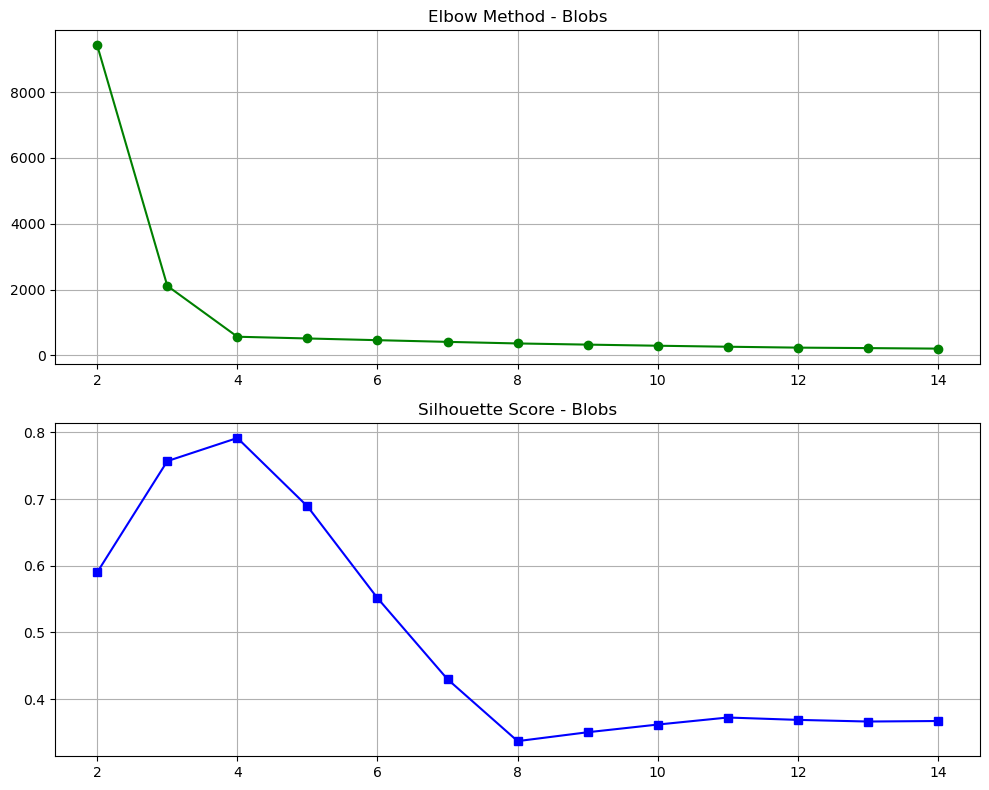

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(k_values, wcss, marker="o", color="green")
axes[0].set_title(f"Elbow Method - {name}")
axes[0].grid(True)

axes[1].plot(k_values, sil_scores, marker="s", color="blue")
axes[1].set_title(f"Silhouette Score - {name}")
axes[1].grid(True)

plt.savefig("Elbow Method and Silhouette Score (Blobs).png",dpi=100)
plt.tight_layout()
plt.show()

## Best K

In [8]:
best_k_wcss = list(k_values)[np.argmax(wcss)]
best_k_sil = list(k_values)[np.argmax(sil_scores)]

print(f"Best k (WCSS): {best_k_wcss}")
print(f"Best k (Silhouette): {best_k_sil}")

Best k (WCSS): 2
Best k (Silhouette): 4


### Model Training using Best K value

In [11]:
final_k = best_k_sil
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

print(f"k={k}, inertia={round(kmeans.inertia_,2)}, silhouette={round(silhouette_score(X, clusters),4)}")

k=14, inertia=564.91, silhouette=0.7916


#### Plot

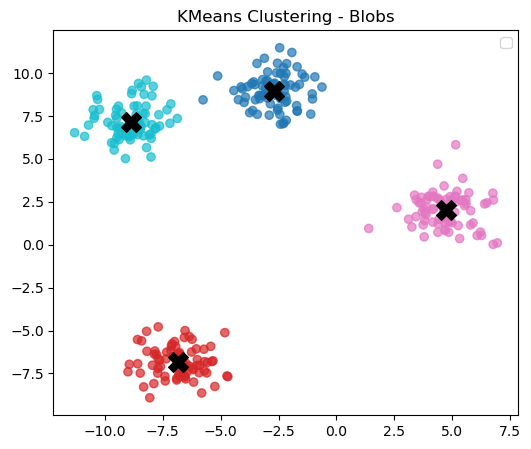

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap="tab10", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker="X", color="black")
plt.title(f"KMeans Clustering - {name}")
plt.savefig("KMeans Clustering (Blobs).png",dpi=100)
plt.legend()
plt.show()